# Exploratory Data Analysis
**COEN 330 - Applied Machine Learning**  
**Dataset:** Loan Application Data (45,000 rows, 14 columns)  
**Task:** Binary classification - predict `loan_status` (1 = Approved, 0 = Rejected)

Per dataset card: `loan_status` is the approval decision (1 = approved, 0 = rejected). We model it directly as a **loan-approval prediction** task.

## Setup

In [49]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))   # make src/ importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths + seed come from the single source of truth in src/utils.py (project convention)
from utils import DATA_RAW, DATASET_FILE, SEED
try:
    from utils import PLOTS_DIR                      # use if utils defines it
except ImportError:
    PLOTS_DIR = DATA_RAW.parent.parent / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)         # ensure dir exists before any savefig

pd.set_option('display.max_columns', None)           # display all columns
sns.set_theme(style='whitegrid', palette='muted')    # theme and palette
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [50]:
df = pd.read_csv(DATA_RAW / DATASET_FILE)

# Target is loan_status: 1 = approved, 0 = rejected

print(f'Shape: {df.shape}')
df.head() # first 5 rows of the dataframe

Shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 2. Basic Dataset Info

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [52]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,45000.0,NaN,NaN,NaN,27.764178,6.045108,20.0,24.0,26.0,30.0,144.0
person_gender,45000,2,male,24841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_education,45000,5,Bachelor,13399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_income,45000.0,NaN,NaN,NaN,80319.053222,80422.498632,8000.0,47204.0,67048.0,95789.25,7200766.0
person_emp_exp,45000.0,NaN,NaN,NaN,5.410333,6.063532,0.0,1.0,4.0,8.0,125.0
person_home_ownership,45000,4,RENT,23443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,45000.0,NaN,NaN,NaN,9583.157556,6314.886691,500.0,5000.0,8000.0,12237.25,35000.0
loan_intent,45000,6,EDUCATION,9153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_int_rate,45000.0,NaN,NaN,NaN,11.006606,2.978808,5.42,8.59,11.01,12.99,20.0
loan_percent_income,45000.0,NaN,NaN,NaN,0.139725,0.087212,0.0,0.07,0.12,0.19,0.66


In [53]:
# Identify input features and target variable
target_column = "loan_status"
X = df.drop(columns=[target_column])
y = df[target_column]

print("\nInput features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(target_column)



Input features:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']

Target variable:
loan_status


## 3. Missing Values

In [54]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


## 4. Target Distribution

**Note:** `loan_status = 1` (Approved) is the **minority class** (~22%); rejected (0) is ~78%. This imbalance must be accounted for in metric selection and model evaluation (class weights, PR-AUC, threshold tuning).

Class distribution:
             Count  Percent
loan_status                
0            35000    77.78
1            10000    22.22


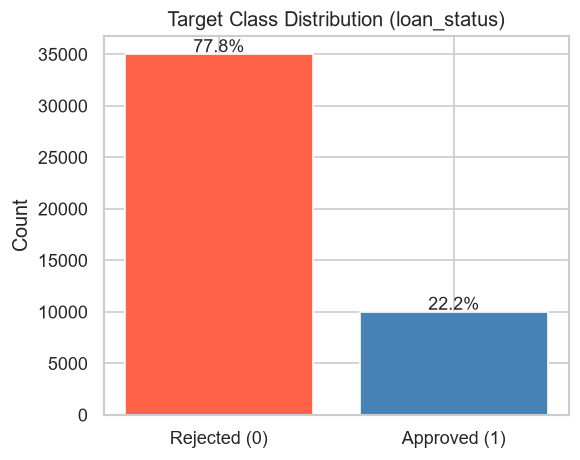

In [55]:
target_counts = df['loan_status'].value_counts()
target_pct = df['loan_status'].value_counts(normalize=True) * 100

print('Class distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percent': target_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Rejected (0)', 'Approved (1)'], target_counts.sort_index(),
              color=['tomato', 'steelblue'], edgecolor='white')
for bar, pct in zip(bars, target_pct.sort_index()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontsize=11)
ax.set_title('Target Class Distribution (loan_status)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'target_distribution.png')
plt.show()

## 5. Numerical Feature Distributions

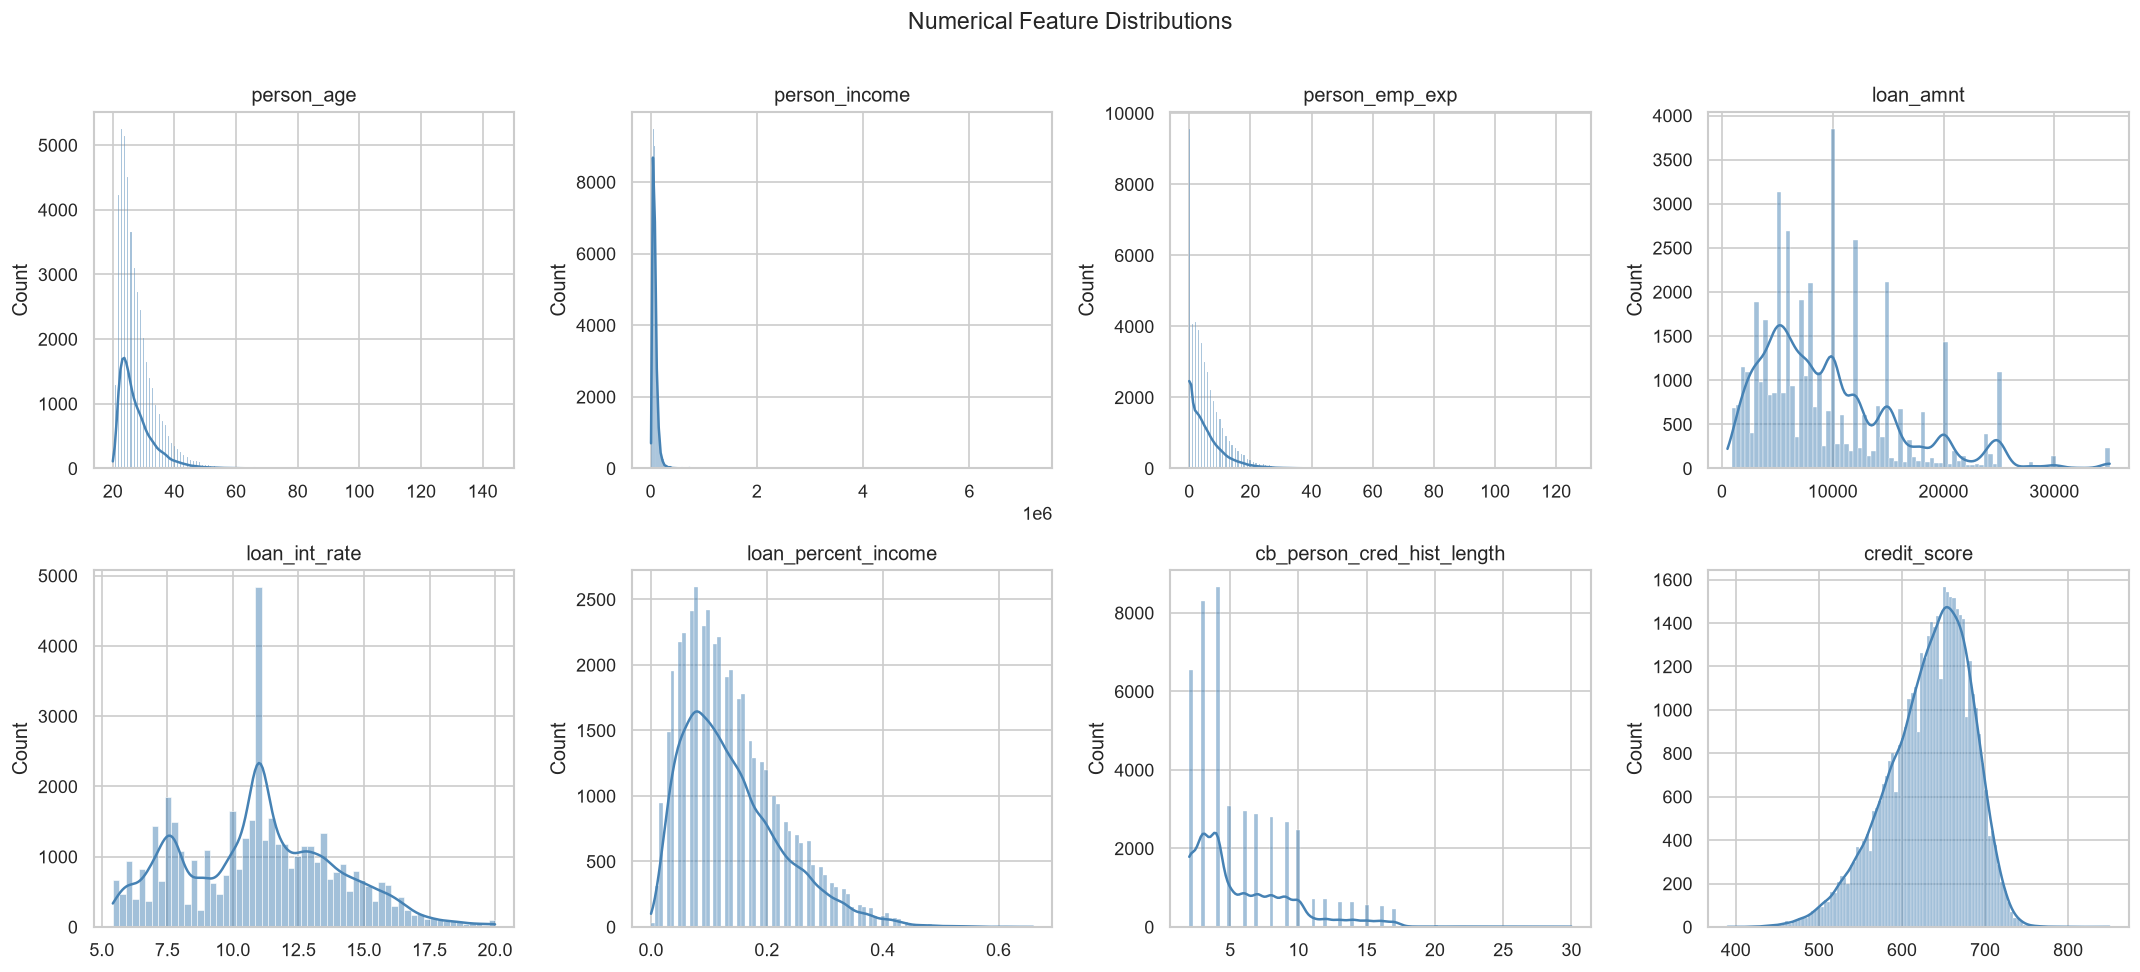

In [56]:
num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'numerical_distributions.png')
plt.show()

### 5.1 Outlier Analysis - `person_age`

`person_age` column contains maximum age of 144, which is biologically impossible, so this is a data quality issue. Therefore, age will be capped at 80 in preprocessing.

person_age statistics:
count    45000.000000
mean        27.764178
std          6.045108
min         20.000000
25%         24.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

Rows with age > 80: 9
Rows with age > 100: 7
person_age skew: raw=2.55, post-cap(80)=1.96


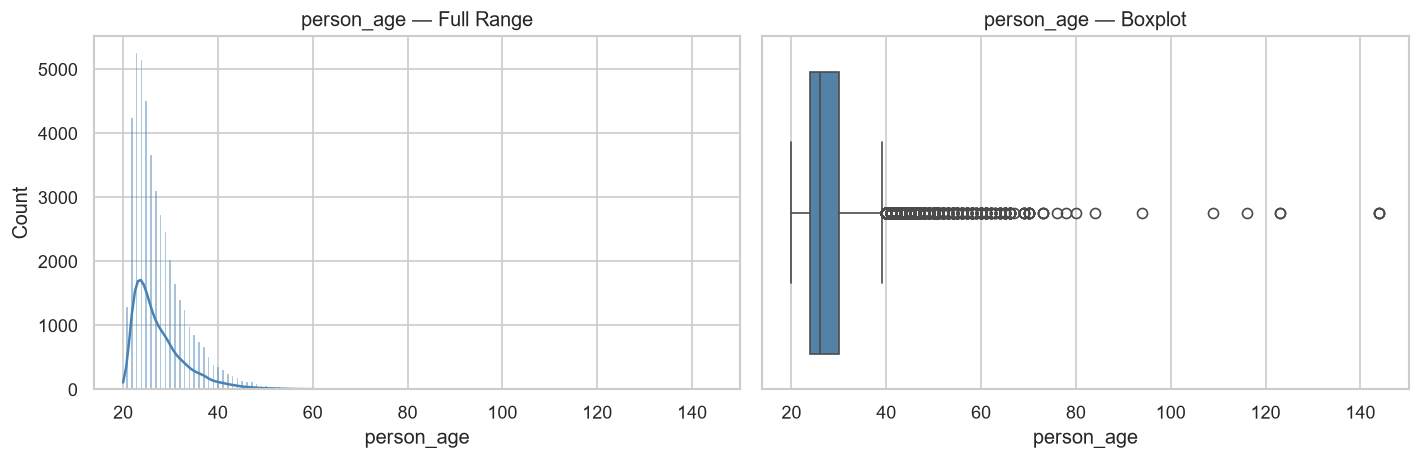

In [57]:
print('person_age statistics:')
print(df['person_age'].describe())
print(f"\nRows with age > 80: {(df['person_age'] > 80).sum()}")
print(f"Rows with age > 100: {(df['person_age'] > 100).sum()}")

age_capped = df['person_age'].clip(upper=80)
print(f'person_age skew: raw={df["person_age"].skew():.2f}, post-cap(80)={age_capped.skew():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['person_age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('person_age - Full Range')
sns.boxplot(x=df['person_age'], ax=axes[1], color='steelblue')
axes[1].set_title('person_age - Boxplot')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'person_age_outliers.png')
plt.show()

### 5.2 Skewness Analysis 

Skewness (sorted):
person_income                 34.14
person_emp_exp                 2.59
person_age                     2.55
cb_person_cred_hist_length     1.63
loan_amnt                      1.18
loan_percent_income            1.03
loan_int_rate                  0.21
credit_score                  -0.61

log1p candidates (|skew| >= 1.0): ['person_income', 'person_emp_exp', 'person_age', 'cb_person_cred_hist_length', 'loan_amnt', 'loan_percent_income']


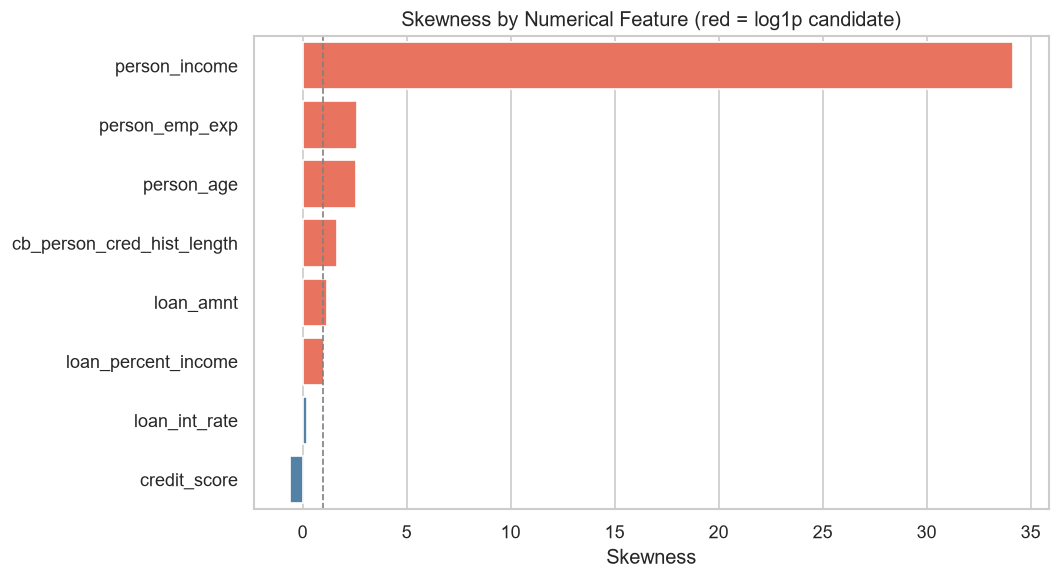

In [58]:
# Decision rule: |skew| >= 1 flags a feature as a possible log1p transformation candidate.
skew = df[num_cols].skew().sort_values(ascending=False)

print('Skewness (sorted):')
print(skew.round(2).to_string())

LOG1P_THRESHOLD = 1.0
candidates = skew[skew.abs() >= LOG1P_THRESHOLD].index.tolist()
print(f'\nlog1p candidates (|skew| >= {LOG1P_THRESHOLD}): {candidates}')

# Visual: skew per feature, with the decision threshold marked
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if abs(s) >= LOG1P_THRESHOLD else 'steelblue' for s in skew]
sns.barplot(x=skew.values, y=skew.index, hue=skew.index, legend=False,
            palette=colors, ax=ax)
ax.axvline(LOG1P_THRESHOLD, color='gray', linestyle='--', linewidth=1)
ax.set_title('Skewness by Numerical Feature (red = log1p candidate)')
ax.set_xlabel('Skewness')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'skewness_summary.png')
plt.show()

In [59]:
# Compare raw skew vs. skew after log1p to identify which log1p transforms are actually helpful.
rows = []
for col in num_cols:
    raw = df[col].skew()
    logged = np.log1p(df[col].clip(lower=0)).skew()   # clips any negatives to avoid log1p issues
    rows.append({
        'feature': col,
        'skew_raw': round(raw, 2),
        'skew_log1p': round(logged, 2),
        'abs_reduction': round(abs(raw) - abs(logged), 2),
    })

skew_tbl = (pd.DataFrame(rows)
            .sort_values('skew_raw', key=abs, ascending=False)
            .reset_index(drop=True))

print('Skewness - raw vs. log1p:')
print(skew_tbl.to_string(index=False))

Skewness - raw vs. log1p:
                   feature  skew_raw  skew_log1p  abs_reduction
             person_income     34.14        0.22          33.91
            person_emp_exp      2.59       -0.12           2.47
                person_age      2.55        1.22           1.33
cb_person_cred_hist_length      1.63        0.44           1.19
                 loan_amnt      1.18       -0.44           0.74
       loan_percent_income      1.03        0.83           0.21
              credit_score     -0.61       -0.85          -0.24
             loan_int_rate      0.21       -0.32          -0.11


From the above table, only person_income and person_emp_exp show a meaningful reduction in skew after log1p, so those are the only 2 features we will log-transform in our preprocessor. The others either had low skew to begin with or log1p did not improve the skew substantially.

### 5.3 Skewness Analysis - `person income` & `employement experience`

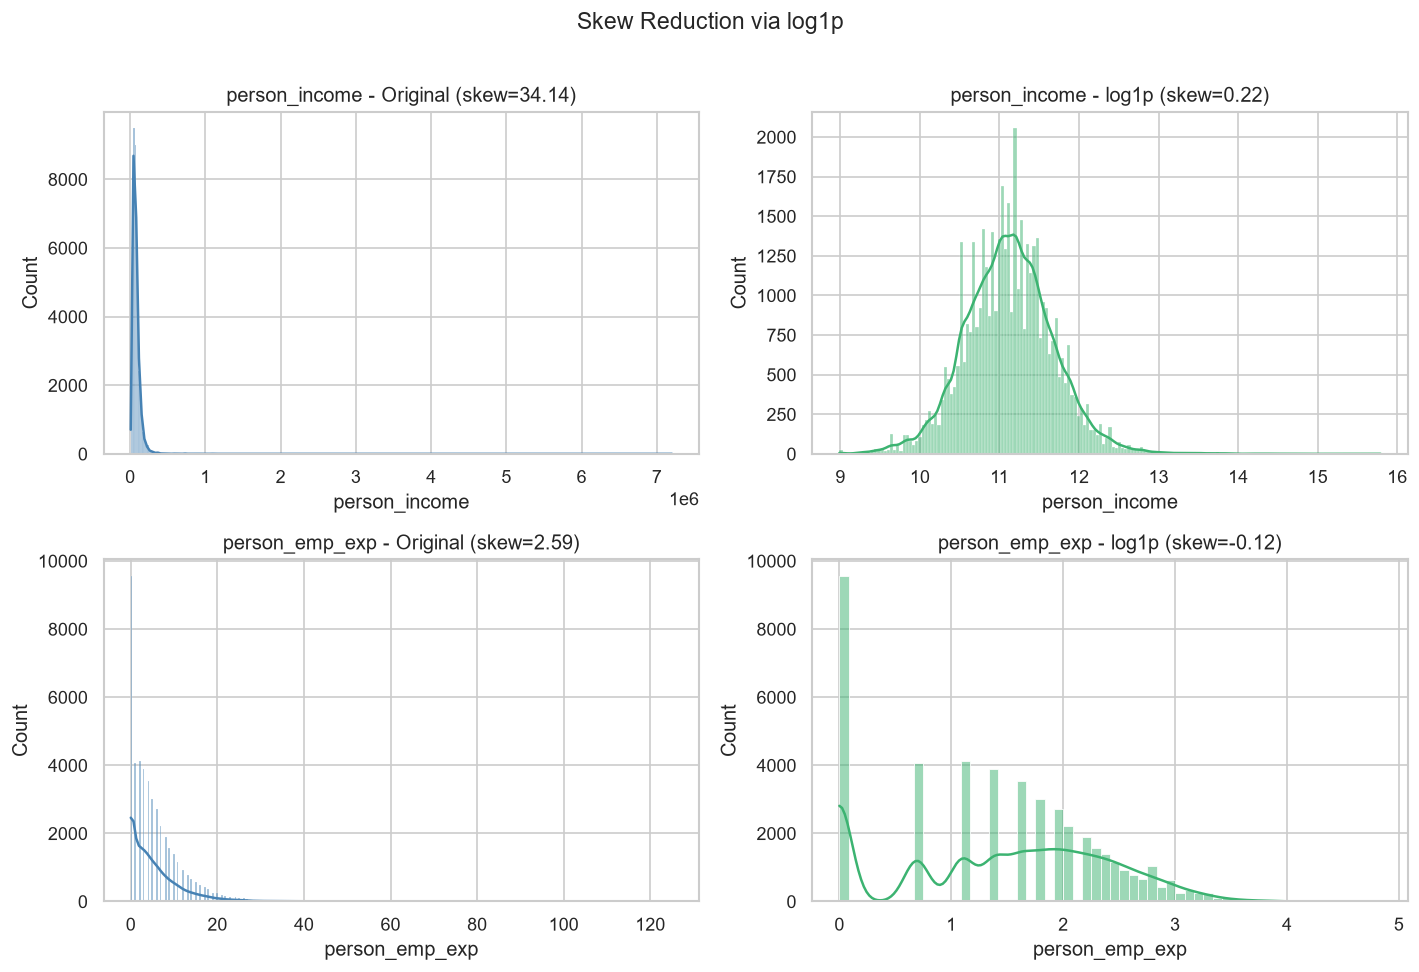

In [60]:
# Skew reduction analysis: log1p applied to the two heavy-tailed features
LOG_FEATURES = ['person_income', 'person_emp_exp']

fig, axes = plt.subplots(len(LOG_FEATURES), 2, figsize=(12, 4 * len(LOG_FEATURES)))
axes = np.atleast_2d(axes)
for row, col in enumerate(LOG_FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[row, 0], color='steelblue')
    axes[row, 0].set_title(f'{col} - Original (skew={df[col].skew():.2f})')
    logged = np.log1p(df[col].clip(lower=0))
    sns.histplot(logged, kde=True, ax=axes[row, 1], color='mediumseagreen')
    axes[row, 1].set_title(f'{col} - log1p (skew={logged.skew():.2f})')
plt.suptitle('Skew Reduction via log1p', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'skew_reduction.png')
plt.show()

## 6. Categorical Feature Distributions

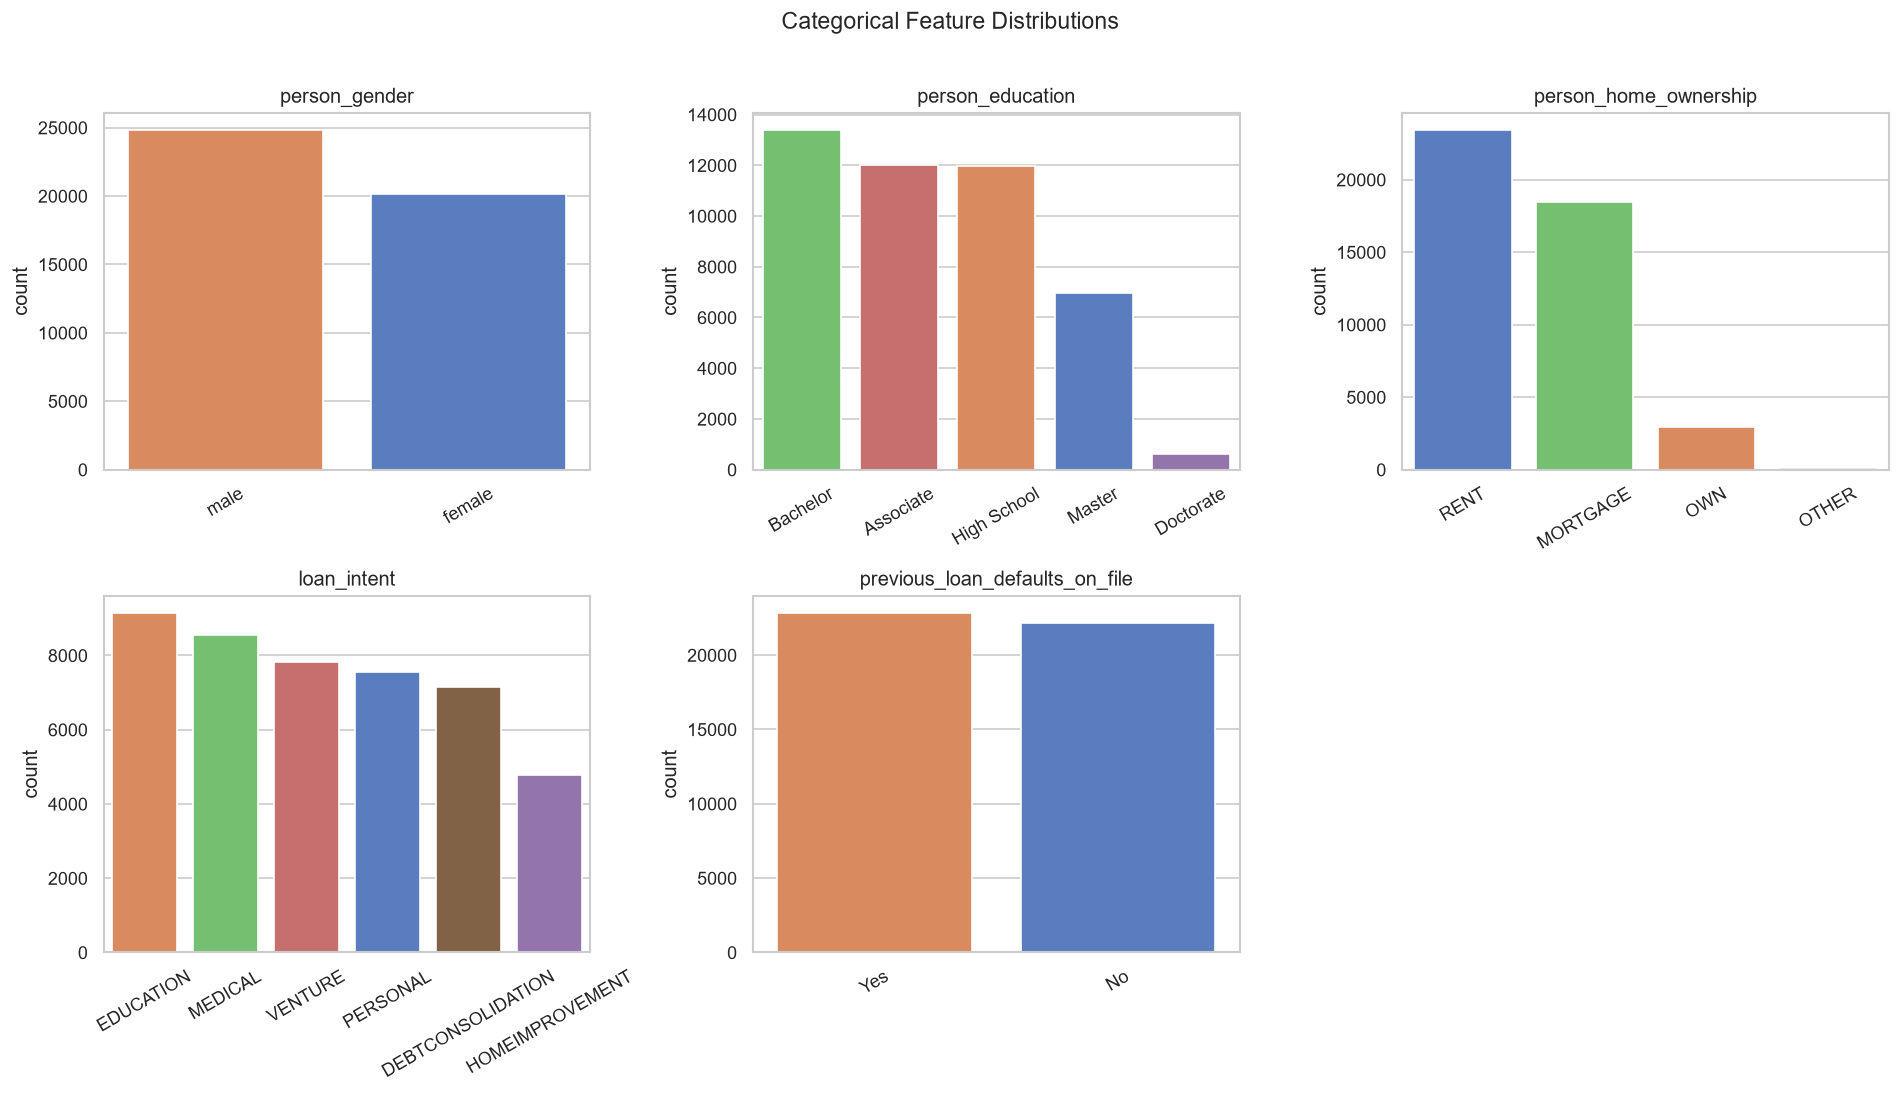

In [61]:
cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, legend=False,
                  palette='muted', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
axes.flatten()[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'categorical_distributions.png')
plt.show()

## 7. Near-perfect Predictor - `previous_loan_defaults_on_file`

**Important finding:** `previous_loan_defaults_on_file = Yes` maps nearly perfectly to `loan_status = 0` (rejected). This feature may make the problem easier than a realistic setting and will be discussed in the report. We therefore train the models WITH and WITHOUT this column and cross-check the findings.

approval rate by previous_loan_defaults_on_file (%):
loan_status                          0      1
previous_loan_defaults_on_file               
No                               54.84  45.16
Yes                             100.00   0.00


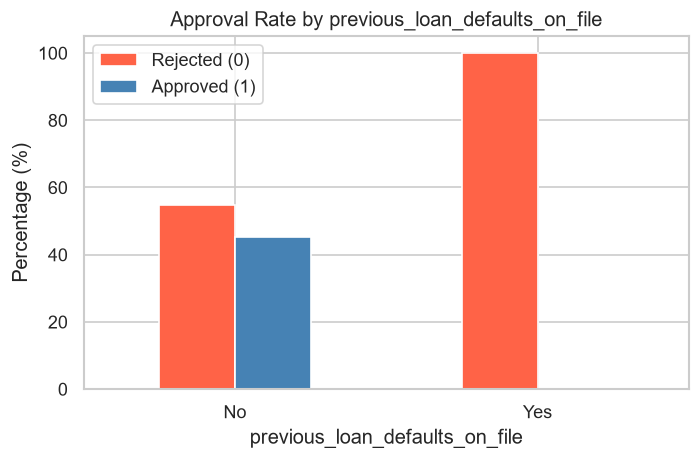

In [62]:
cross = pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'],
                    normalize='index') * 100
print('approval rate by previous_loan_defaults_on_file (%):')
print(cross.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
cross.plot(kind='bar', ax=ax, color=['tomato', 'steelblue'], edgecolor='white')
ax.set_title('Approval Rate by previous_loan_defaults_on_file')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('previous_loan_defaults_on_file')
ax.legend(['Rejected (0)', 'Approved (1)'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'defaults_vs_approval.png')
plt.show()

### 7.1 Approval Rate by Other Categoricals

Approval-rate per category for the remaining nominal/ordinal features.

approval rate by person_education (%):
person_education
Doctorate      22.87
Bachelor       22.52
High School    22.31
Associate      22.03
Master         21.76

approval rate by person_home_ownership (%):
person_home_ownership
OTHER       33.33
RENT        32.40
MORTGAGE    11.60
OWN          7.52

approval rate by loan_intent (%):
loan_intent
DEBTCONSOLIDATION    30.27
MEDICAL              27.82
HOMEIMPROVEMENT      26.30
PERSONAL             20.14
EDUCATION            16.96
VENTURE              14.43

approval rate by person_gender (%):
person_gender
female    22.25
male      22.20



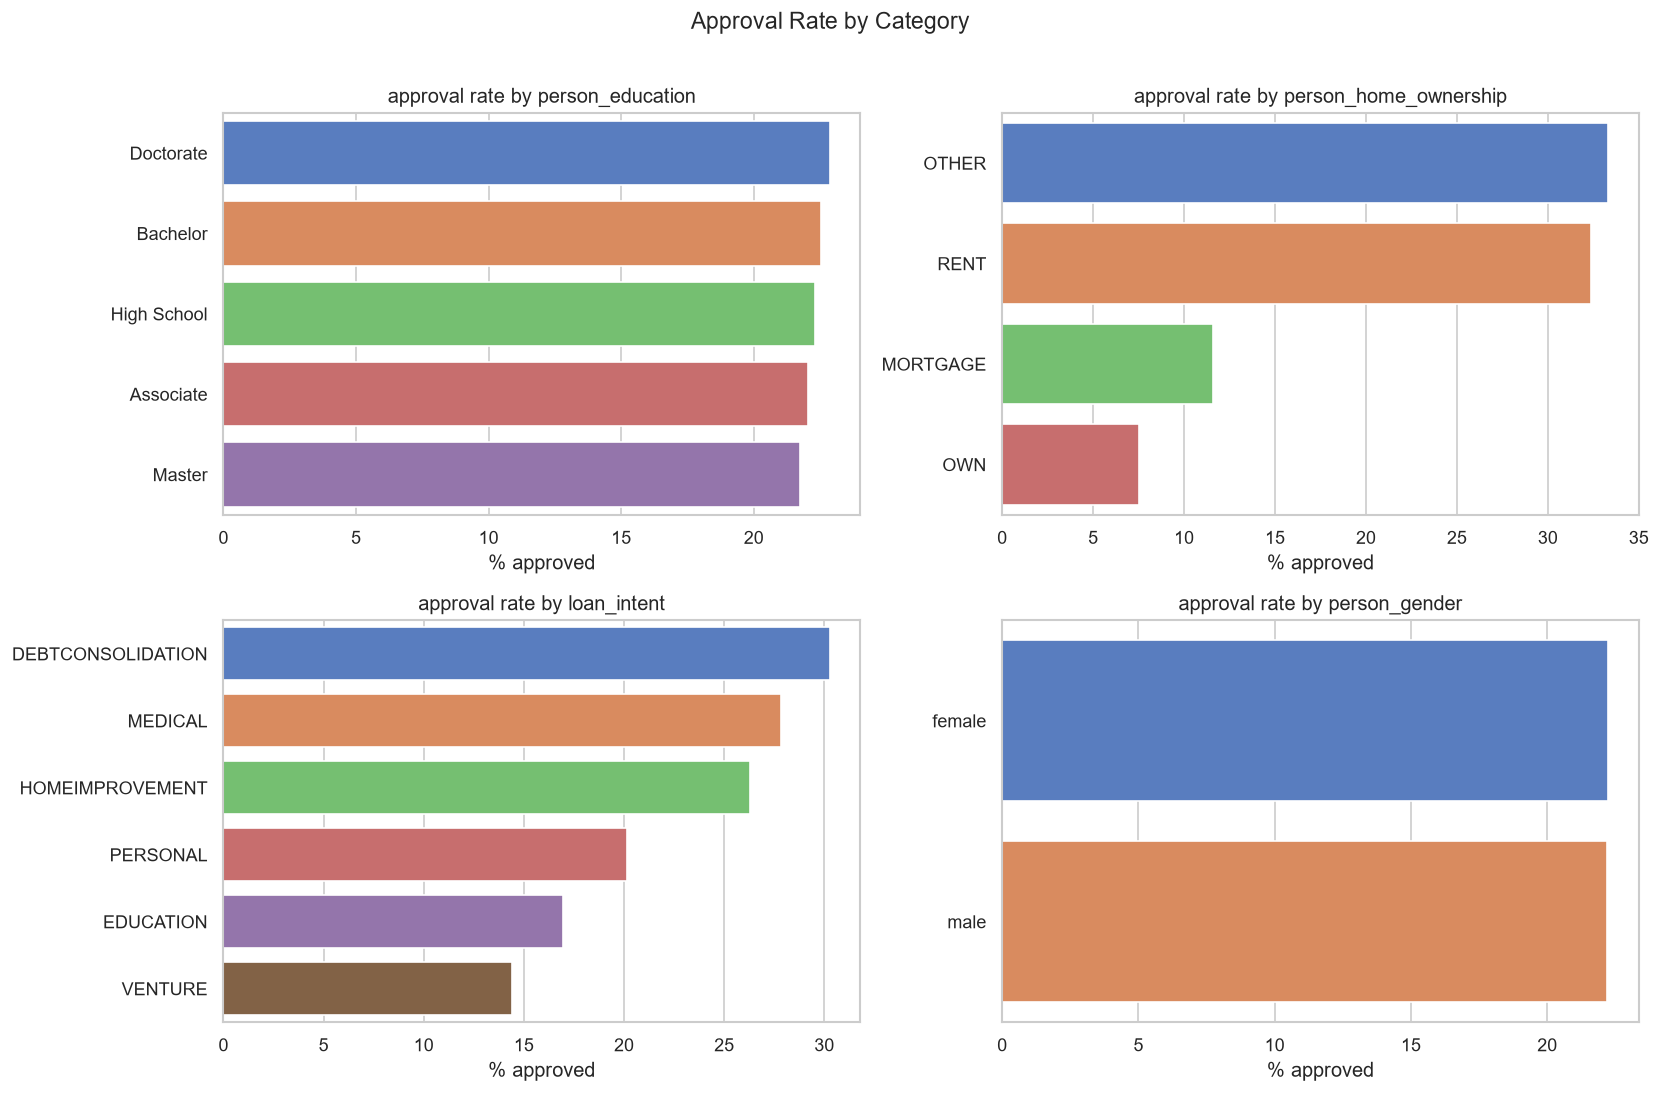

In [63]:
rate_cols = ['person_education', 'person_home_ownership', 'loan_intent', 'person_gender']

for col in rate_cols:
    rate = df.groupby(col)['loan_status'].mean().mul(100).sort_values(ascending=False).round(2)
    print(f'approval rate by {col} (%):')
    print(rate.to_string())
    print()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), rate_cols):
    rate = df.groupby(col)['loan_status'].mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, hue=rate.index, legend=False,
                palette='muted', ax=ax)
    ax.set_title(f'approval rate by {col}')
    ax.set_xlabel('% approved')
    ax.set_ylabel('')
plt.suptitle('Approval Rate by Category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'approval_rate_by_category.png')
plt.show()

## 8. Feature vs. Target Relationships

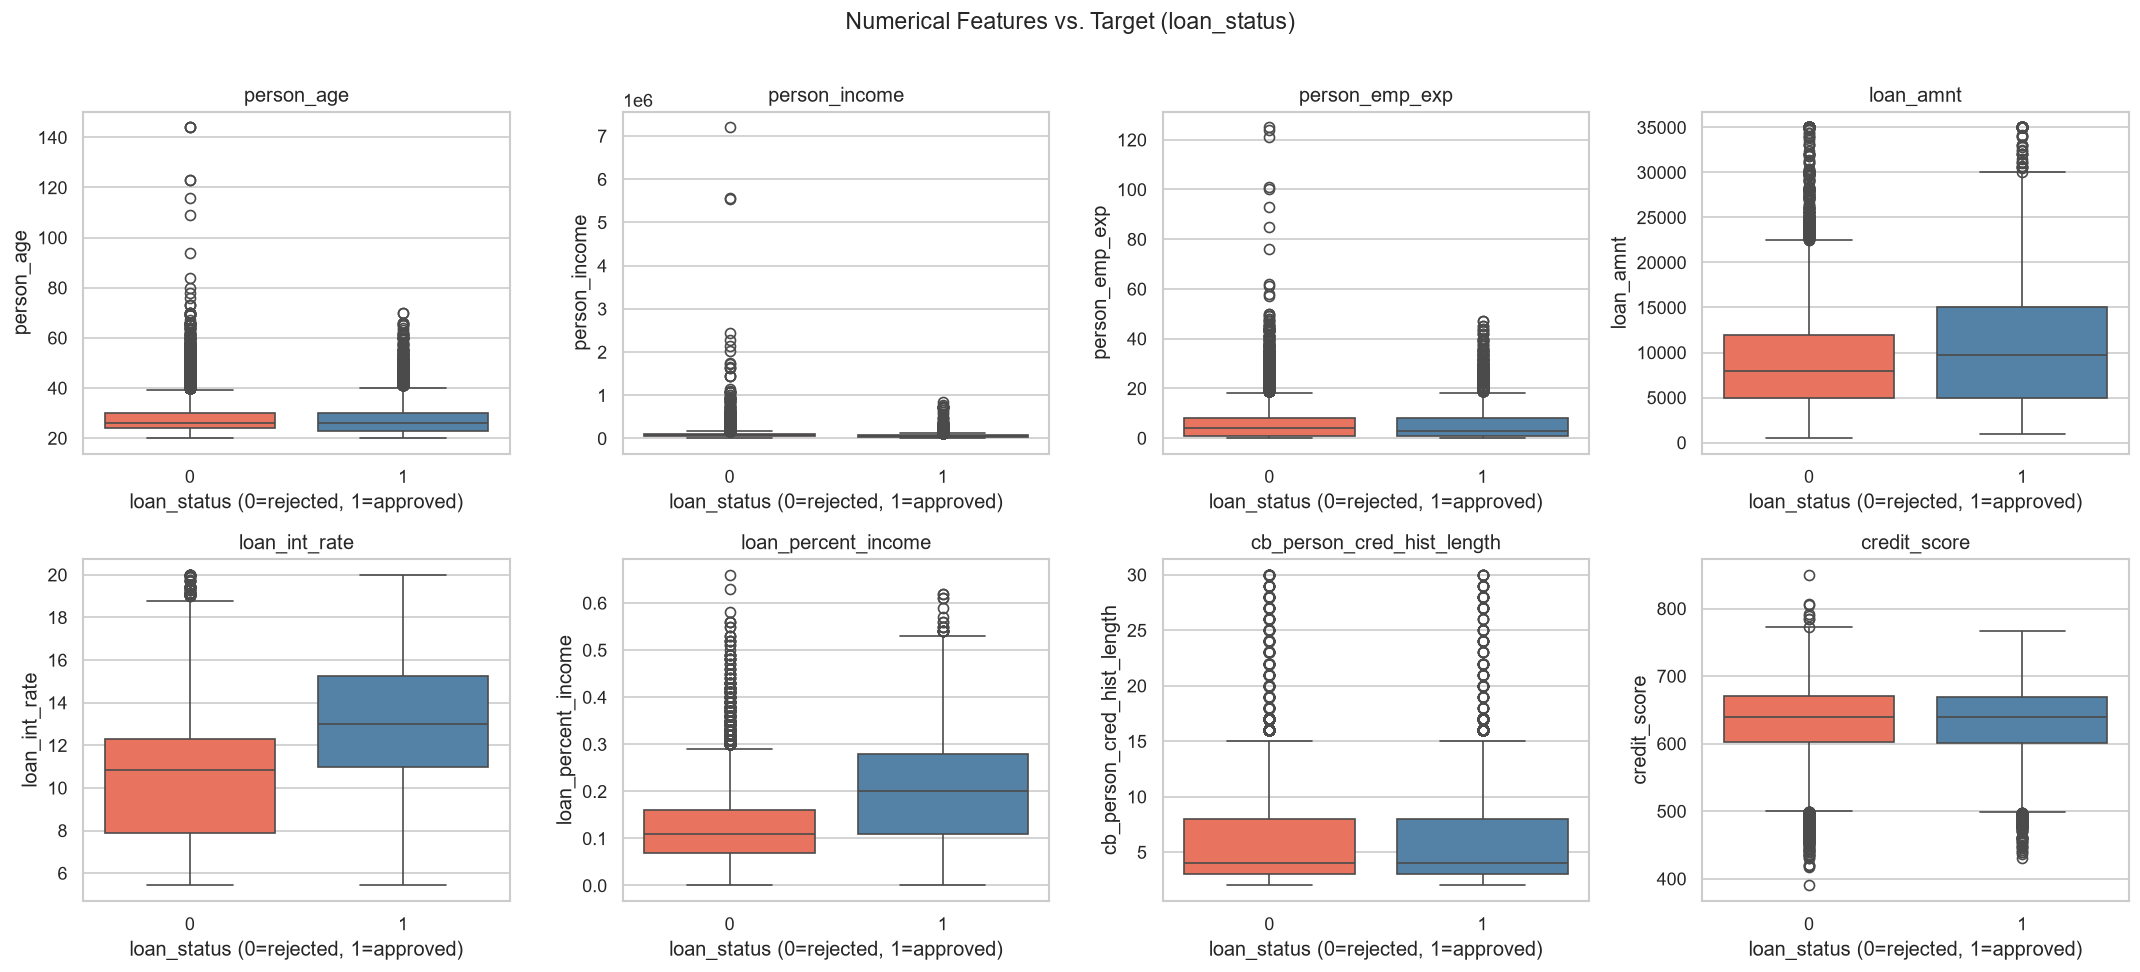

In [64]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    # hue + legend=False: seaborn >=0.14 requires hue to use a palette
    sns.boxplot(data=df, x='loan_status', y=col, hue='loan_status', legend=False,
                palette={0: 'tomato', 1: 'steelblue'}, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('loan_status (0=rejected, 1=approved)')
plt.suptitle('Numerical Features vs. Target (loan_status)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'numerical_vs_target.png')
plt.show()

### 8.1 Distribution Shape by Approval Status (Violin Plots)

Violins complement the boxplots above: they show the full density of each numerical feature per class, not just the quartiles.

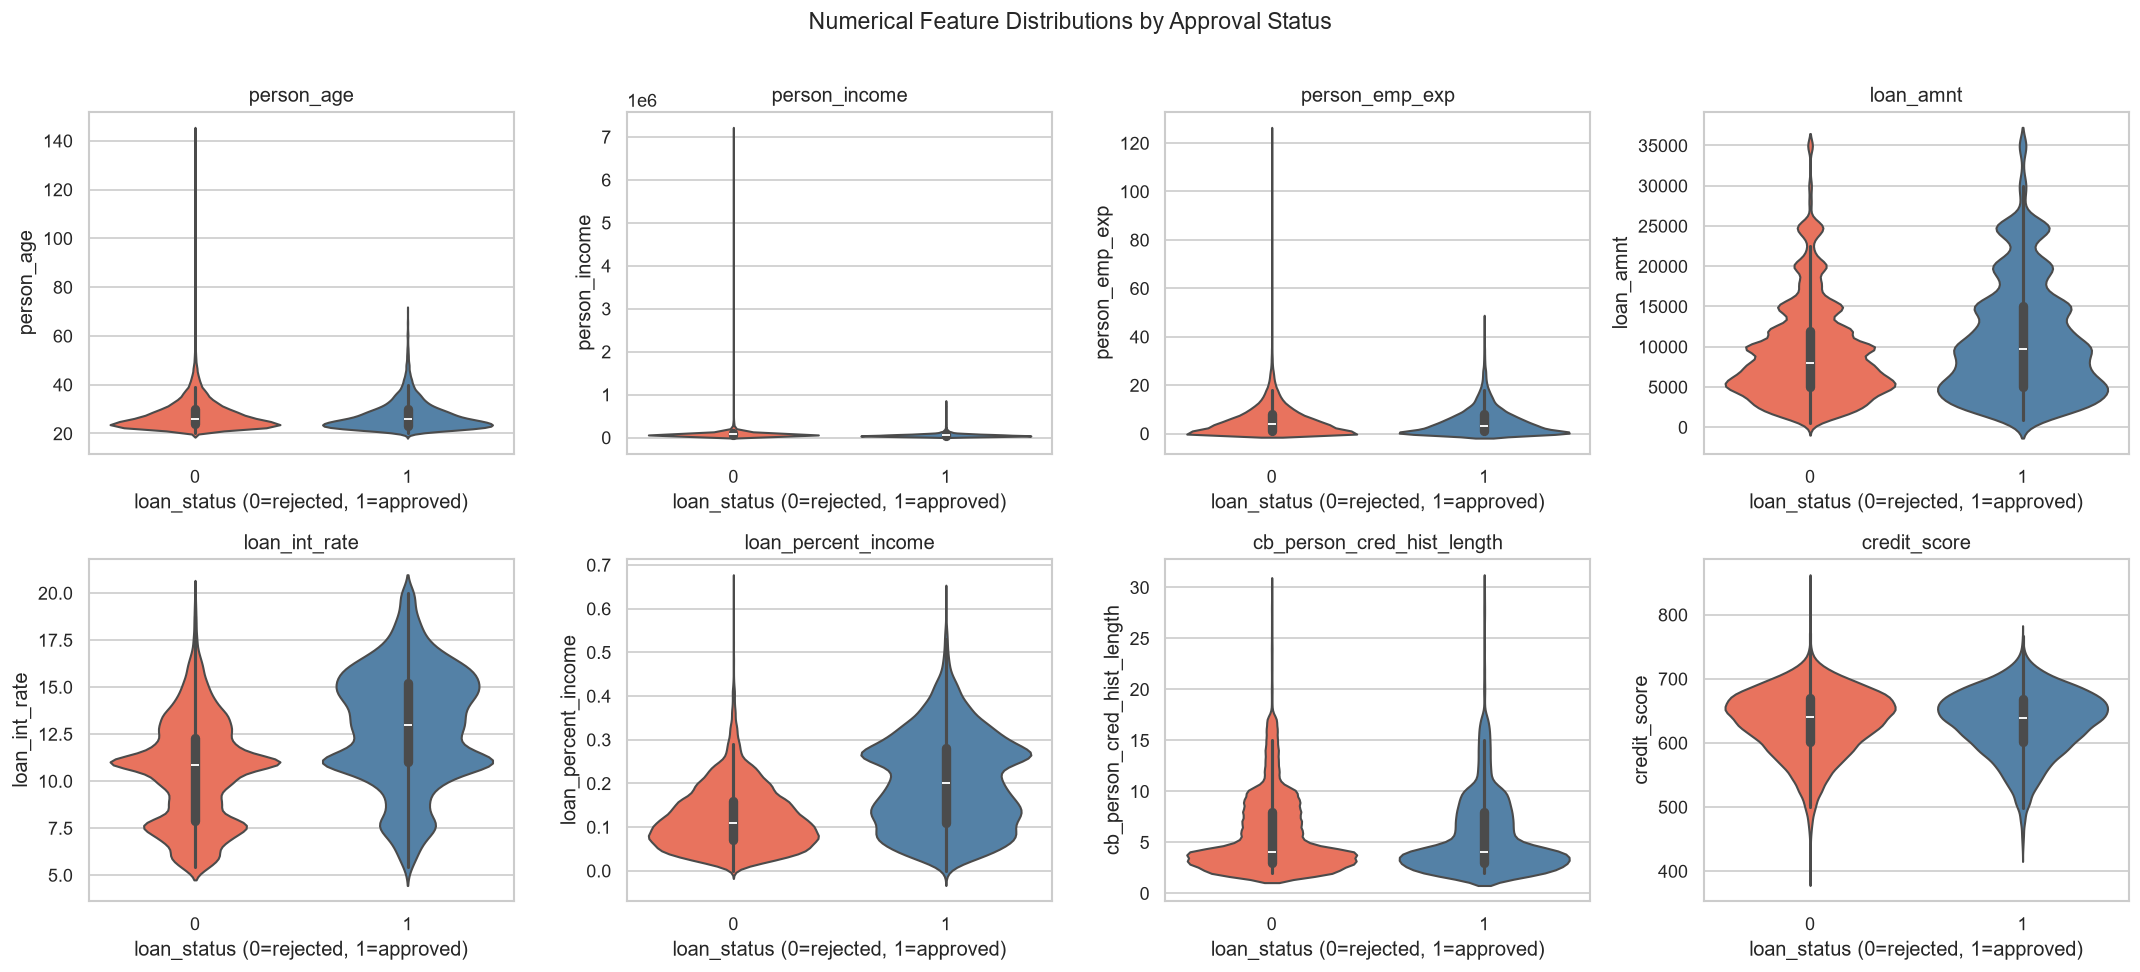

In [65]:
# Violin plots: full distribution of each numerical feature by approval class.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.violinplot(data=df, x='loan_status', y=col, hue='loan_status',
                   legend=False, palette={0: 'tomato', 1: 'steelblue'}, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('loan_status (0=rejected, 1=approved)')
plt.suptitle('Numerical Feature Distributions by Approval Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'numerical_violin_by_target.png')
plt.show()

## 9. Correlation Heatmap

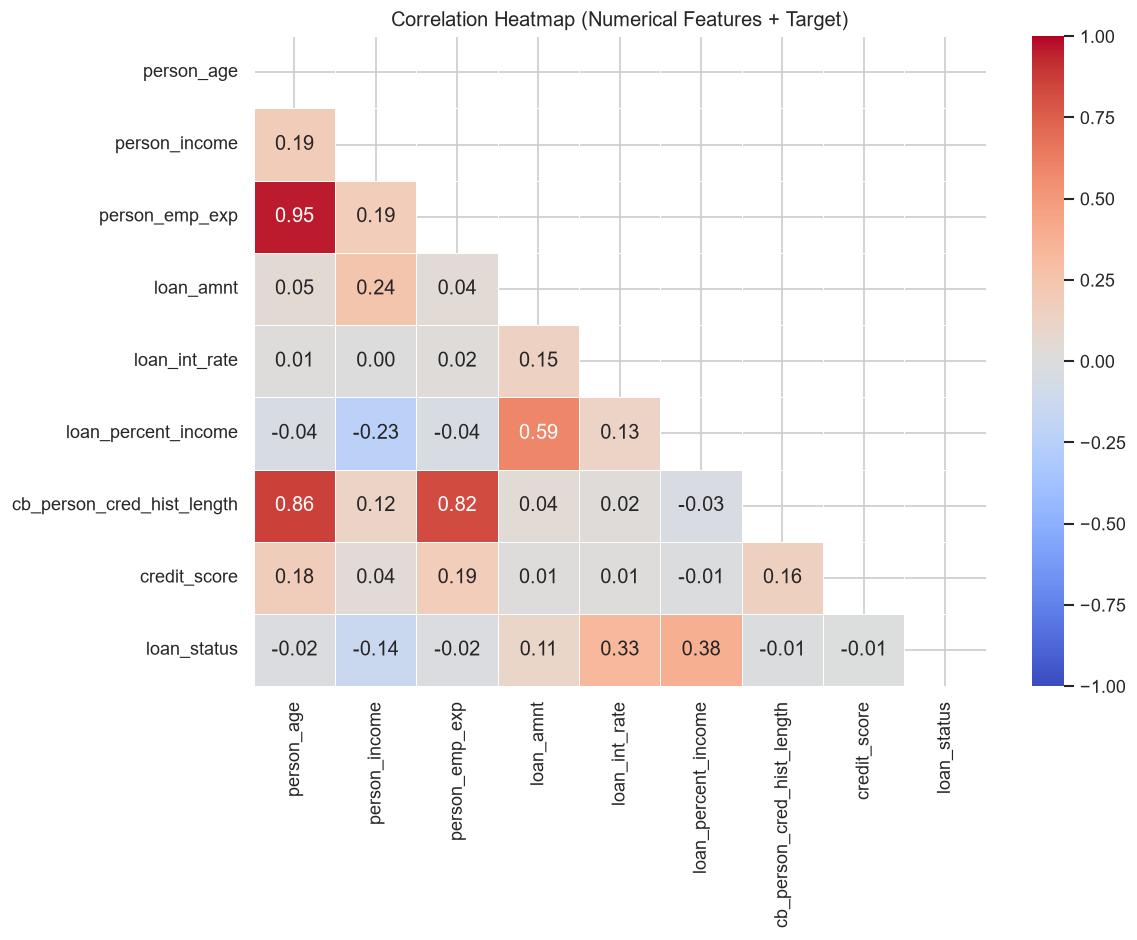

In [66]:
corr_cols = num_cols + ['loan_status']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap (Numerical Features + Target)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmap.png')
plt.show()

### 9.1 Collinearity Check - `loan_percent_income`

By construction `loan_percent_income = loan_amnt / person_income`, so it is mechanically
collinear with both. Therefore, it might be redundant in our feature set.

In [67]:
# loan_percent_income = loan_amnt / person_income (derived from two other features), 
# so check whether it is redundant with its components. 

# Severe collinearity is conventionally |r| >= 0.8.
COLLINEARITY_THRESHOLD = 0.8

collinear = corr.loc['loan_percent_income', ['loan_amnt', 'person_income']]
max_abs_corr = collinear.abs().max()
worst = collinear.abs().idxmax()

print('loan_percent_income correlation with its components:')
print(collinear.round(3).to_string())
print(f'\nMax |correlation| = {max_abs_corr:.3f} (with {worst}), threshold = {COLLINEARITY_THRESHOLD}')

if max_abs_corr >= COLLINEARITY_THRESHOLD:
    print(f'=> SEVERE collinearity. Consider dropping loan_percent_income or one of its component feature.')
else:
    print(f'=> Below threshold. Keep loan_percent_income since it carries independent information,')
    print(f'   and as a debt-to-income ratio it is a meaningful credit-risk feature.')

loan_percent_income correlation with its components:
loan_amnt        0.593
person_income   -0.234

Max |correlation| = 0.593 (with loan_amnt), threshold = 0.8
=> Below threshold. Keep loan_percent_income since it carries independent information,
   and as a debt-to-income ratio it is a meaningful credit-risk feature.


## 10. EDA Summary

| Finding | Detail | Action |
|---|---|---|
| No missing values | All 14 columns complete | No imputation needed |
| Class imbalance | ~22% Approved (1), ~78% Rejected (0) | Class weights + PR-AUC / balanced accuracy / recall on the minority (approved); threshold tuning, vs a majority-class dummy baseline |
| `person_age` outliers | Max = 144 (invalid) | Cap at 80 in preprocessing |
| `person_income` and `person_emp_exp` skewness | Heavily right-skewed and substantial skew reduction possibility | Apply log1p transform |
| `previous_loan_defaults_on_file` | Near-perfect predictor of approval | Train models WITH and WITHOUT it |
| `loan_percent_income` | Not heavily collinear with `loan_amnt` & `person_income` (derived) | Keep this feature since it carries independent information |
| `person_education` | Ordinal (5 levels) | Use Ordinal encoding |
| `person_gender` | Approval rate differs by group | Flag for fairness / bias discussion in report |
| `loan_status` | Target variable (1 = approved) | Predicted directly; excluded from feature matrix |
